In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (6, 5) # Set default figure size
plt.rcParams["figure.dpi"] = 300 # vector format (e.g., SVG, PDF, EPS) is recommended for publication-quality figures

print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")
df = pd.read_csv("/Users/xiahanfei/Desktop/MGS3001/AI_music/FINAL_ANALYSIS_DATA_CLEANED.csv")

pandas: 3.0.2
seaborn: 0.13.2


In [11]:
df.describe()

,comment_count,song_id,MFCC1_Spectral_Energy_Balance,MFCC2_Timbre_Brightness,MFCC3_Spectral_Slope_Characteristic,MFCC4_Harmonic_Structure_1,MFCC5_Harmonic_Structure_2,MFCC6_Vocal_Resonance_1,MFCC7_Vocal_Resonance_2,MFCC8_Tone_Color_Detail_1,...,original_audio_aigc,original_lyric_aigc,melody_aigc,harmony_aigc,structure_aigc,arrangement_aigc,vocal_aigc,mix_aigc,master_aigc,ai_permeability
count,575.000000,5.750000e+02,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,...,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000
mean,11280.766957,1.793574e+09,-123.583349,96.772655,11.298540,17.696398,5.531569,4.264942,-1.826760,1.195910,...,0.179993,0.199732,0.050395,0.037821,0.037821,0.125941,0.054033,0.017977,0.017977,0.090090
std,33896.248928,5.644989e+08,76.023252,18.509546,12.855810,8.260838,6.079650,5.696719,5.524767,5.420579,...,0.174175,0.189452,0.048748,0.036592,0.036592,0.121900,0.052291,0.017418,0.017418,0.063955
min,1.000000,7.739800e+04,-364.556915,42.923794,-57.779526,-10.690185,-15.380112,-23.024471,-22.950233,-18.700891,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,727.500000,1.387607e+09,-149.949059,85.119225,2.315508,12.276524,1.586351,0.855205,-5.154794,-2.702712,...,0.063500,0.059000,0.018000,0.013000,0.013000,0.044500,0.019000,0.006000,0.006000,0.046000
50%,2121.000000,1.895050e+09,-110.821587,96.252197,10.455543,17.611902,6.163081,4.363767,-1.734652,1.453157,...,0.124000,0.146000,0.035000,0.026000,0.026000,0.087000,0.037000,0.012000,0.012000,0.071000
75%,6576.000000,2.067369e+09,-75.816410,108.713234,19.525552,24.076272,8.986280,8.096545,1.340752,4.550644,...,0.232000,0.287000,0.065000,0.049000,0.049000,0.162000,0.070000,0.023000,0.023000,0.122000
max,331242.000000,3.380558e+09,6.548503,155.424881,56.642925,48.610489,30.213528,25.659845,25.886337,22.026339,...,1.000000,1.000000,0.280000,0.210000,0.210000,0.700000,0.300000,0.100000,0.100000,0.324000


In [ ]:
import pandas as pd
df = pd.read_csv("/Users/xiahanfei/Desktop/MGS3001/AI_music/FINAL_ANALYSIS_DATA_CLEANED.csv")
print("="*60)
print("EXACT column names from your file (copy these exactly!):")
for col in df.columns:
    print(f"  '{col}'")
print("="*60)

EXACT column names from your file (copy these exactly!):
  'music_genre_x'
  'artist_name'
  'song_name'
  'music_genre_y'
  'album_name'
  'release_date'
  'comment_count'
  'song_id'
  'MFCC1_Spectral_Energy_Balance'
  'MFCC2_Timbre_Brightness'
  'MFCC3_Spectral_Slope_Characteristic'
  'MFCC4_Harmonic_Structure_1'
  'MFCC5_Harmonic_Structure_2'
  'MFCC6_Vocal_Resonance_1'
  'MFCC7_Vocal_Resonance_2'
  'MFCC8_Tone_Color_Detail_1'
  'MFCC9_Tone_Color_Detail_2'
  'MFCC10_Tone_Color_Detail_3'
  'MFCC11_Bass_Feature'
  'MFCC12_Mid_Frequency_Feature'
  'MFCC13_High_Frequency_Feature'
  'Novelty'
  'log_comment_count'
  'Usefulness'
  'original_audio_aigc'
  'original_lyric_aigc'
  'melody_aigc'
  'harmony_aigc'
  'structure_aigc'
  'arrangement_aigc'
  'vocal_aigc'
  'mix_aigc'
  'master_aigc'
  'ai_permeability'


Generating new meaningful heatmap...


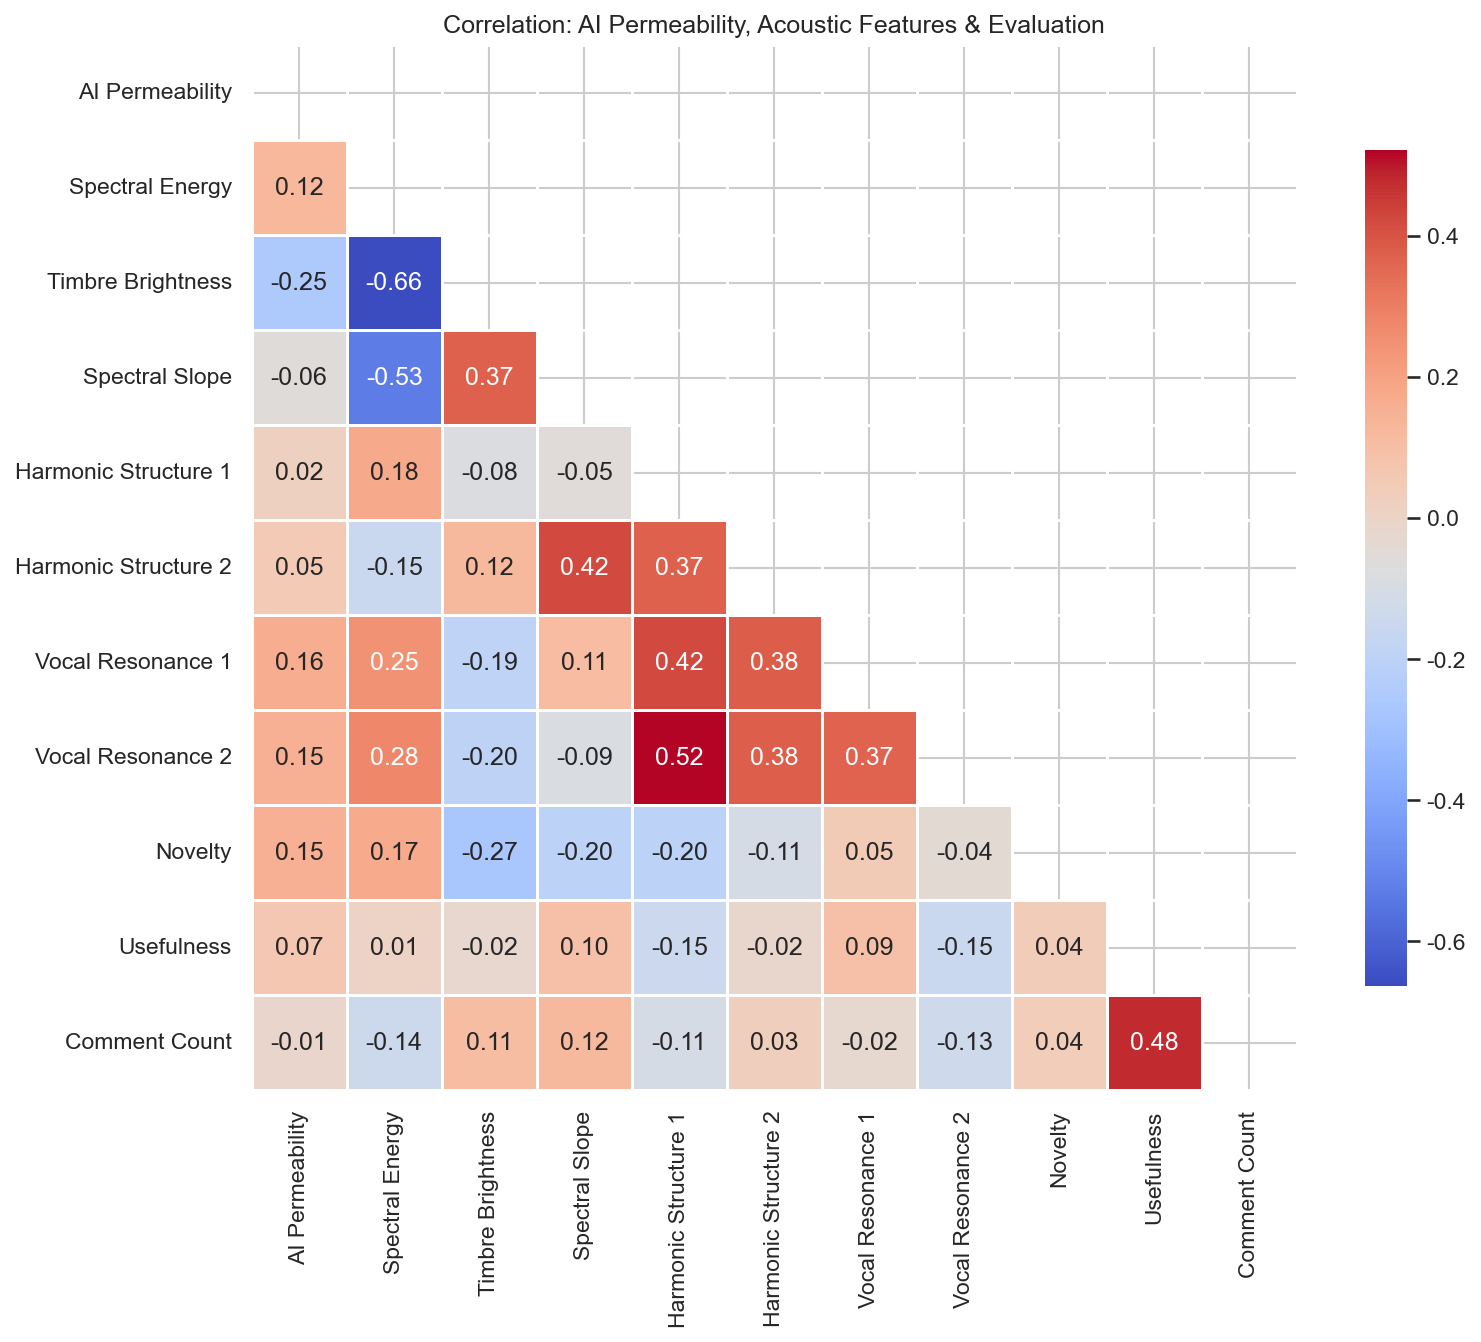


Generating distribution plot...


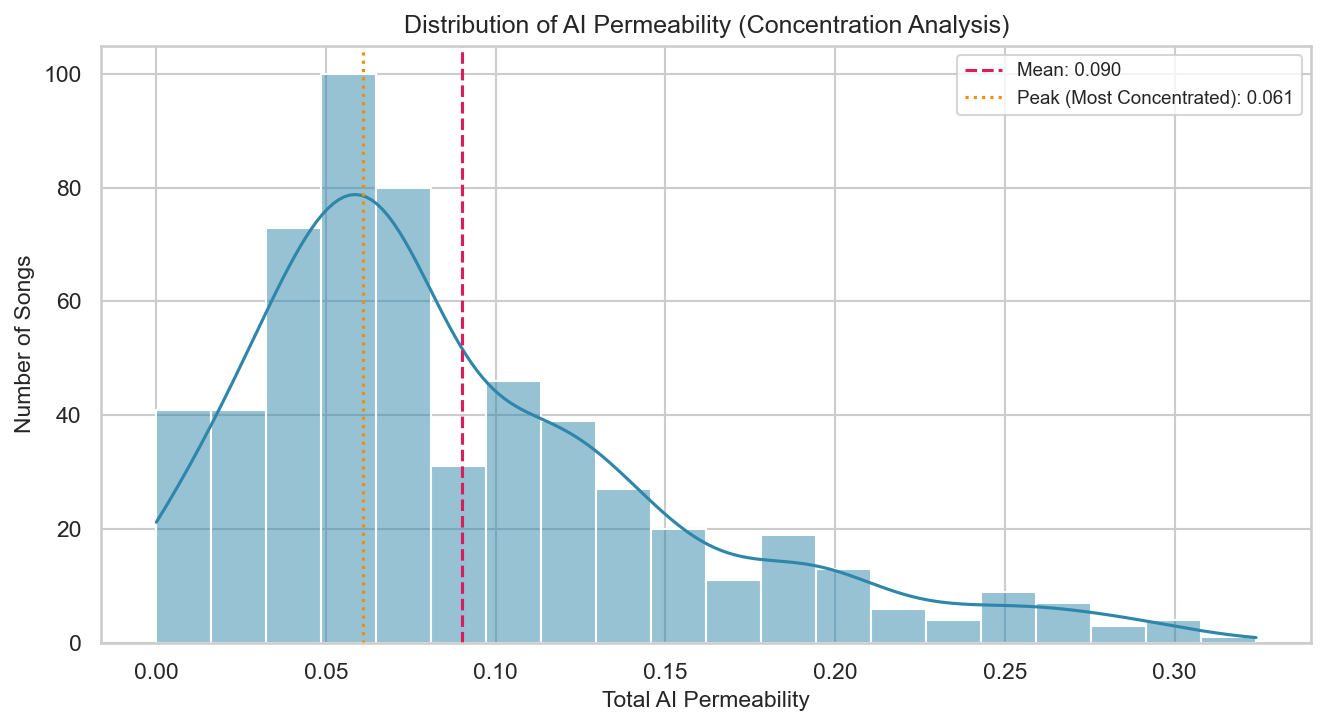

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== Configuration ====================
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

# 读取你的干净数据
df = pd.read_csv("/Users/xiahanfei/Desktop/MGS3001/AI_music/FINAL_ANALYSIS_DATA_CLEANED.csv")

# ==================== 1. New Meaningful Heatmap ====================
# 选有研究价值的变量：
# - 总的AI渗透率
# - 核心声学特征（MFCC那些，代表歌曲的声音特点）
# - 用户评价：Novelty & Usefulness
# - 流行度：评论数
heatmap_vars = [
    # AI指标
    'ai_permeability',
    # 声学特征
    'MFCC1_Spectral_Energy_Balance',
    'MFCC2_Timbre_Brightness',
    'MFCC3_Spectral_Slope_Characteristic',
    'MFCC4_Harmonic_Structure_1',
    'MFCC5_Harmonic_Structure_2',
    'MFCC6_Vocal_Resonance_1',
    'MFCC7_Vocal_Resonance_2',
    # 用户评价
    'Novelty',
    'Usefulness',
    # 流行度
    'comment_count'
]

# 英文标签，适配你的报告
var_names = {
    'ai_permeability': 'AI Permeability',
    'MFCC1_Spectral_Energy_Balance': 'Spectral Energy',
    'MFCC2_Timbre_Brightness': 'Timbre Brightness',
    'MFCC3_Spectral_Slope_Characteristic': 'Spectral Slope',
    'MFCC4_Harmonic_Structure_1': 'Harmonic Structure 1',
    'MFCC5_Harmonic_Structure_2': 'Harmonic Structure 2',
    'MFCC6_Vocal_Resonance_1': 'Vocal Resonance 1',
    'MFCC7_Vocal_Resonance_2': 'Vocal Resonance 2',
    'Novelty': 'Novelty',
    'Usefulness': 'Usefulness',
    'comment_count': 'Comment Count'
}

df_heat = df[heatmap_vars].rename(columns=var_names)

print("Generating new meaningful heatmap...")
plt.figure(figsize=(11, 9))
corr = df_heat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
# 你后续可以自己改cmap颜色
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation: AI Permeability, Acoustic Features & Evaluation', fontsize=12)
plt.tight_layout()
plt.show()

# ==================== 2. AI Permeability Distribution Plot (这个还是保留，看集中情况) ====================
print("\nGenerating distribution plot...")
plt.figure(figsize=(9, 5))
sns.histplot(data=df_heat, x='AI Permeability', bins=20, kde=True, color='#2E86AB')

mean_val = df_heat['AI Permeability'].mean()
peak_val = df_heat['AI Permeability'].mode()[0]
plt.axvline(mean_val, color='#D81E5B', linestyle='--', 
            label=f'Mean: {mean_val:.3f}')
plt.axvline(peak_val, color='#F18F01', linestyle=':', 
            label=f'Peak (Most Concentrated): {peak_val:.3f}')

plt.xlabel('Total AI Permeability', fontsize=11)
plt.ylabel('Number of Songs', fontsize=11)
plt.title('Distribution of AI Permeability (Concentration Analysis)', fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [33]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set(font_scale=1.2, style="white")
plt.rcParams['font.sans-serif'] = ['Arial']

# 读取你的数据
df = pd.read_csv("/Users/xiahanfei/Desktop/MGS3001/AI_music/FINAL_ANALYSIS_DATA_CLEANED.csv")

# 画图
plt.figure(figsize=(10, 6))
# 散点
sns.scatterplot(x='ai_permeability', y='Novelty', data=df, alpha=0.6, s=50)
# 二次拟合曲线，直接展示倒U型趋势
sns.regplot(x='ai_permeability', y='Novelty', data=df, scatter=False, order=2, line_kws={'color':'red', 'lw':2})

plt.xlabel('AI Permeability', fontsize=12)
plt.ylabel('Novelty', fontsize=12)
plt.title('The Non-linear Relationship between AI Permeability and Novelty', fontsize=14)
plt.tight_layout()
plt.savefig('nonlinear_fit.png', dpi=300)

In [34]:
# 给AI渗透度分组，对应我们的4种模式
def get_participation_mode(p):
    if p < 0.05:
        return '1. Inspirational'
    elif p < 0.2:
        return '2. Auxiliary'
    elif p < 0.7:
        return '3. Co-creation'
    else:
        return '4. Full Autonomous'

df['mode'] = df['ai_permeability'].apply(get_participation_mode)

# 画图
plt.figure(figsize=(10, 6))
sns.boxplot(x='mode', y='Novelty', data=df, order=['1. Inspirational', '2. Auxiliary', '3. Co-creation', '4. Full Autonomous'])

plt.xlabel('AI Participation Mode', fontsize=12)
plt.ylabel('Novelty', fontsize=12)
plt.title('Novelty across Different Human-AI Co-creation Modes', fontsize=14)
plt.tight_layout()
plt.savefig('mode_boxplot.png', dpi=300)

In [40]:
pip install ipython nbformat==4.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [nbformat]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [41]:

import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 读取你自己的本地数据
df = pd.read_csv("/Users/xiahanfei/Desktop/MGS3001/AI_music/FINAL_ANALYSIS_DATA_CLEANED.csv")

# 先做二次拟合，得到拟合曲线
z = np.polyfit(df['ai_permeability'], df['Novelty'], 2)
p = np.poly1d(z)
x_range = np.linspace(0, 1, 100)
y_fit = p(x_range)

# 画图
fig = go.Figure()
# 加散点
fig.add_trace(go.Scatter(
    x=df['ai_permeability'], y=df['Novelty'],
    mode='markers',
    name='Samples',
    marker=dict(opacity=0.6, size=8)
))
# 加拟合曲线
fig.add_trace(go.Scatter(
    x=x_range, y=y_fit,
    mode='lines',
    name='Quadratic Fit',
    line=dict(color='red', width=3)
))

# 布局设置
fig.update_layout(
    title='The Non-linear Relationship between AI Permeability and Novelty',
    xaxis_title='AI Permeability',
    yaxis_title='Novelty',
    template='plotly_white',
    font=dict(family='Arial', size=12)
)

# 显示图表，你现在就能直接在输出的图表里改颜色了！
fig.show()

# 如果你想保存成html，之后打开也能改，运行这个：
# fig.write_html("interactive_plot.html")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [45]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 全局设置，适配英文论文
sns.set(font_scale=1.2, style="white")
plt.rcParams['font.sans-serif'] = ['Arial']

# --------------------------
# 把这里的路径改成你本地的CSV文件路径！
df = pd.read_csv("/Users/xiahanfei/Desktop/MGS3001/AI_music/FINAL_ANALYSIS_DATA_CLEANED.csv")
# --------------------------

plt.figure(figsize=(10, 6))

# 画Novelty的散点和拟合线
sns.scatterplot(x='ai_permeability', y='Novelty', data=df, 
                alpha=0.4, s=50, color='#2E86AB', label='Novelty (Samples)')
sns.regplot(x='ai_permeability', y='Novelty', data=df, 
            scatter=False, order=2, line_kws={'color':'#2E86AB', 'lw':3}, label='Novelty (Quadratic Fit)')

# 画Usefulness的散点和拟合线
sns.scatterplot(x='ai_permeability', y='Usefulness', data=df, 
                alpha=0.4, s=50, color='#D81E5B', label='Usefulness (Samples)')
sns.regplot(x='ai_permeability', y='Usefulness', data=df, 
            scatter=False, order=2, line_kws={'color':'#D81E5B', 'lw':3}, label='Usefulness (Quadratic Fit)')

# 布局设置
plt.xlabel('AI Permeability', fontsize=12)
plt.ylabel('Creative Score', fontsize=12)
plt.title('Non-linear Relationship between AI Permeability and Creative Dimensions', fontsize=14)
plt.legend()
plt.tight_layout()

# 保存成SVG矢量图，之后可以直接改颜色
plt.savefig('dual_dimension_fit.svg', dpi=300)
print("双维度拟合图已生成：dual_dimension_fit.svg")

双维度拟合图已生成：dual_dimension_fit.svg


In [47]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 全局设置，适配英文论文
sns.set(font_scale=1.2, style="white")
plt.rcParams['font.sans-serif'] = ['Arial']

# --------------------------
# 把这里的路径改成你本地的CSV文件路径！
df = pd.read_csv("/Users/xiahanfei/Desktop/MGS3001/AI_music/FINAL_ANALYSIS_DATA_CLEANED.csv")
# --------------------------

# ✨ 改了这里！先自动筛选所有数值列，再排除核心变量，再也不会把文本列混进去了！
numeric_cols = df.select_dtypes(include=[np.number]).columns
acoustic_cols = [col for col in numeric_cols if col not in 
                 ['ai_permeability', 'Novelty', 'Usefulness', 'comment_count']]

# 计算每个声学特征和AI渗透度的相关系数
corrs = df[acoustic_cols].corrwith(df['ai_permeability']).sort_values()

plt.figure(figsize=(10, 8))
# 画条形图
sns.barplot(x=corrs.values, y=corrs.index, palette='vlag')

# 加一条0线，区分正负相关
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# 布局设置
plt.xlabel('Correlation Coefficient with AI Permeability', fontsize=12)
plt.ylabel('Acoustic Feature', fontsize=12)
plt.title('Correlation between Acoustic Features and AI Participation', fontsize=14)
plt.tight_layout()

# 保存成SVG矢量图，之后可以直接改颜色
plt.savefig('acoustic_correlation_bar.svg', dpi=300)
print("声学特征相关性图已生成：acoustic_correlation_bar.svg")

声学特征相关性图已生成：acoustic_correlation_bar.svg


In [48]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 全局设置，适配英文论文
sns.set(font_scale=1.2, style="white")
plt.rcParams['font.sans-serif'] = ['Arial']

# --------------------------
# 把这里的路径改成你本地的CSV文件路径！
df = pd.read_csv("/Users/xiahanfei/Desktop/MGS3001/AI_music/FINAL_ANALYSIS_DATA_CLEANED.csv")
# --------------------------

# ✨ 改了这里！先自动筛选所有数值列，再排除核心变量，再也不会把文本列混进去了！
numeric_cols = df.select_dtypes(include=[np.number]).columns
acoustic_cols = [col for col in numeric_cols if col not in 
                 ['ai_permeability', 'Novelty', 'Usefulness', 'comment_count']]

# 计算每个声学特征和AI渗透度的相关系数
corrs = df[acoustic_cols].corrwith(df['ai_permeability']).sort_values()

plt.figure(figsize=(10, 8))
# 画条形图
sns.barplot(x=corrs.values, y=corrs.index, palette='vlag')

# 加一条0线，区分正负相关
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# 布局设置
plt.xlabel('Correlation Coefficient with AI Permeability', fontsize=12)
plt.ylabel('Acoustic Feature', fontsize=12)
plt.title('Correlation between Acoustic Features and AI Participation', fontsize=14)
plt.tight_layout()

# 保存成SVG矢量图，之后可以直接改颜色
plt.savefig('acoustic_correlation_bar.svg', dpi=300)
print("声学特征相关性图已生成：acoustic_correlation_bar.svg")

声学特征相关性图已生成：acoustic_correlation_bar.svg
